**Диагностика Инсульта**

In [ ]:
!pip install -q segmentation-models-pytorch albumentations gradio

import os, cv2, torch, numpy as np, matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from google.colab import drive

drive.mount('/content/drive')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Работаем на: {device}")

Mounted at /content/drive
✅ Работаем на: cuda


In [ ]:
zip_path = "/content/drive/MyDrive/CourseWork/Brain_Stroke_CT_Dataset.zip"

if not os.path.exists('/content/dataset'):
    print("📦 Распаковка данных...")
    !unzip -q "{zip_path}" -d /content/dataset
    print("✅ Готово!")

all_images = []
all_masks = []

files = glob('/content/dataset/**/*.png', recursive=True) + glob('/content/dataset/**/*.PNG', recursive=True)

for f in files:
    path_l = f.lower()
    if '/png/' in path_l and '/overlay/' not in path_l:
        all_images.append(f)
        mask_p = f.replace('/PNG/', '/OVERLAY/').replace('/png/', '/overlay/').replace('/Png/', '/Overlay/')
        all_masks.append(mask_p if os.path.exists(mask_p) else None)

print(f"Всего снимков: {len(all_images)}")
print(f"Снимков с инсультом: {sum(1 for m in all_masks if m is not None)}")

📦 Распаковка данных...
✅ Готово!
Всего снимков: 6850
Снимков с инсультом: 2423


In [ ]:
class StrokeDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images, self.masks, self.transform = images, masks, transform

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.images[idx]), cv2.COLOR_BGR2RGB)

        if self.masks[idx] is None:
            mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.float32)
        else:
            hsv = cv2.cvtColor(cv2.imread(self.masks[idx]), cv2.COLOR_BGR2HSV)
            mask = cv2.inRange(hsv, np.array([0, 50, 50]), np.array([10, 255, 255])) | \
                   cv2.inRange(hsv, np.array([170, 50, 50]), np.array([180, 255, 255]))
            mask = (mask > 0).astype(np.float32)

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']
        return img, mask.unsqueeze(0)

transforms = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

tr_i, val_i, tr_m, val_m = train_test_split(all_images, all_masks, test_size=0.2, random_state=42)
train_loader = DataLoader(StrokeDataset(tr_i, tr_m, transforms), batch_size=8, shuffle=True)
val_loader = DataLoader(StrokeDataset(val_i, val_m, transforms), batch_size=8)

In [ ]:
# Создаем модель U-Net с предобученным энкодером EfficientNet
model = smp.Unet(encoder_name="efficientnet-b4", encoder_weights="imagenet", in_channels=3, classes=1).to(device)

# Функция потерь Dice
criterion = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Цикл обучения
epochs = 40
for epoch in range(epochs):
    model.train()
    loss_sum = 0
    for imgs, msks in tqdm(train_loader, desc=f"Эпоха {epoch+1}"):
        imgs, msks = imgs.to(device), msks.to(device)
        optimizer.zero_grad()
        output = model(imgs)
        loss = criterion(output, msks)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
    print(f"Средняя потеря: {loss_sum/len(train_loader):.4f}")

torch.save(model.state_dict(), "stroke_model.pth")

Эпоха 1: 100%|██████████| 685/685 [03:12<00:00,  3.57it/s]


Средняя потеря: 0.7923


Эпоха 2: 100%|██████████| 685/685 [03:17<00:00,  3.47it/s]


Средняя потеря: 0.4806


Эпоха 3: 100%|██████████| 685/685 [03:16<00:00,  3.48it/s]


...

Средняя потеря: 0.1610


Эпоха 39: 100%|██████████| 685/685 [03:10<00:00,  3.59it/s]


Средняя потеря: 0.1575


Эпоха 40: 100%|██████████| 685/685 [03:11<00:00,  3.58it/s]


Средняя потеря: 0.1529


Глубокий анализ: 100%|██████████| 172/172 [00:18<00:00,  9.33it/s]


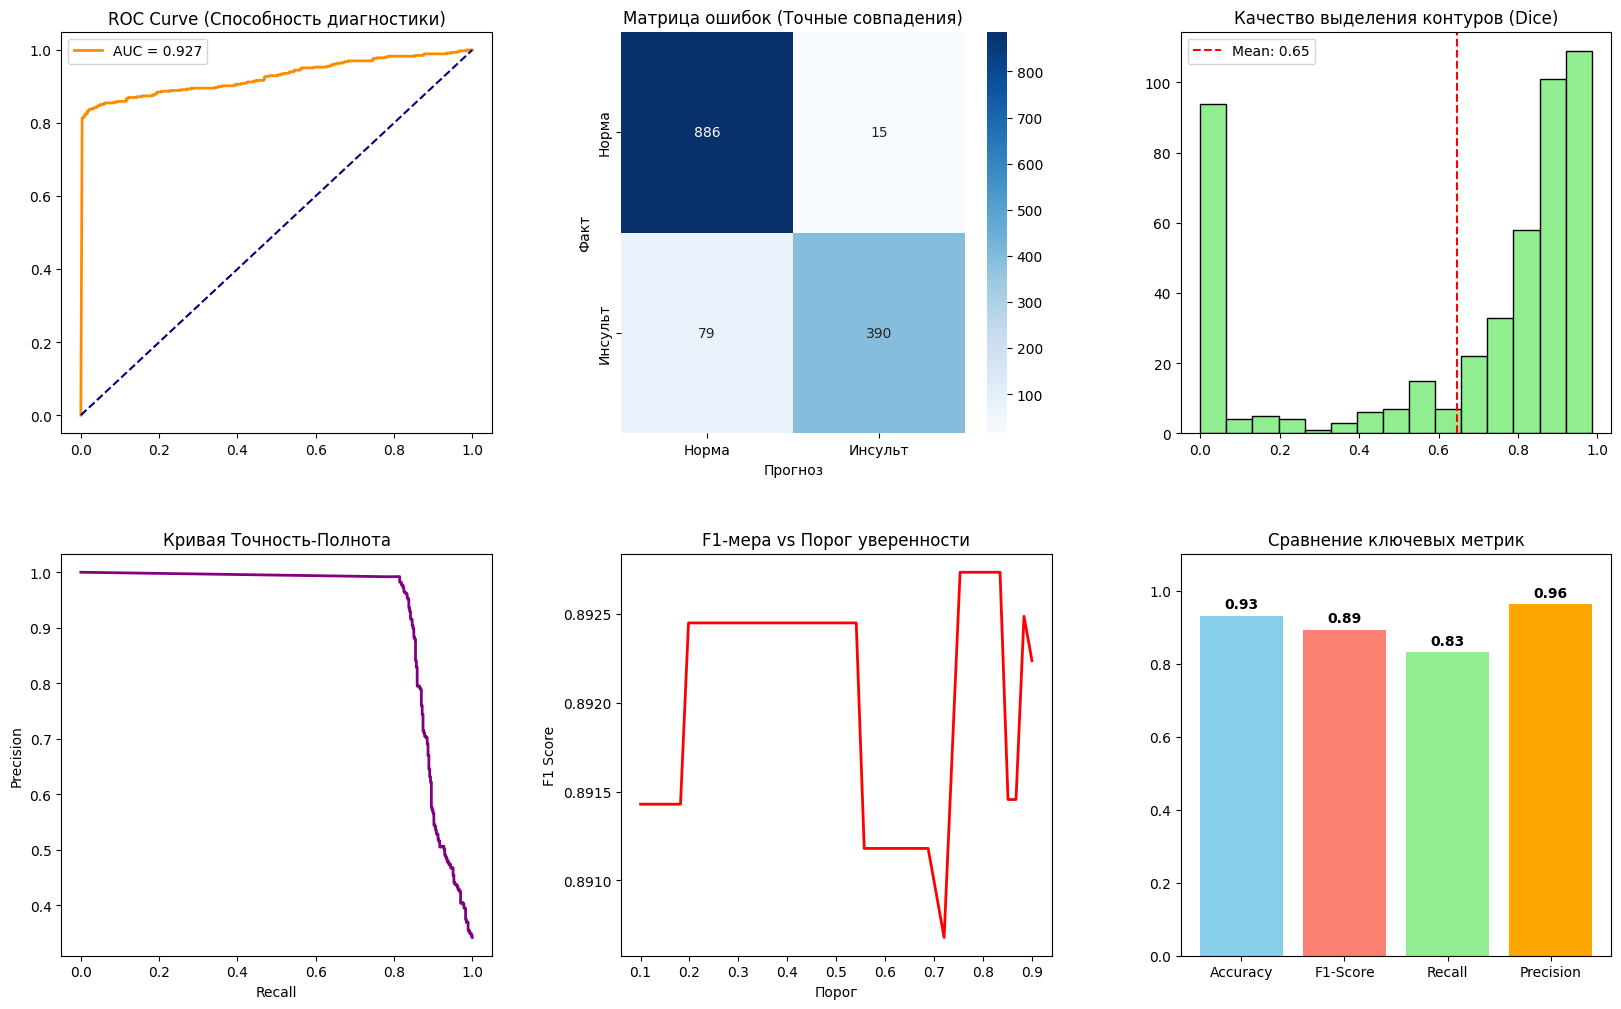


                    ИТОГОВЫЙ ОТЧЕТ ДИАГНОСТИКИ
               precision    recall  f1-score   support

Здоровый мозг     0.9181    0.9834    0.9496       901
      Инсульт     0.9630    0.8316    0.8924       469

     accuracy                         0.9314      1370
    macro avg     0.9405    0.9075    0.9210      1370
 weighted avg     0.9335    0.9314    0.9301      1370


----------------------------------------
 ТЕХНИЧЕСКИЕ ПОКАЗАТЕЛИ СЕГМЕНТАЦИИ:
 > Коэффициент Дайса (Dice): 0.6475 (Качество наложения масок)
 > IoU (Jaccard Index):     0.5689 (Пересечение областей)
 > Точность по пикселям:    0.9943
----------------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                             classification_report, accuracy_score,
                             precision_score, recall_score, f1_score,
                             precision_recall_curve)

def scientific_report():
    model.eval()
    all_probs, all_preds, all_gt = [], [], []
    dice_scores, iou_scores, pixel_accuracies = [], [], []

    with torch.no_grad():
        for imgs, msks in tqdm(val_loader, desc="Глубокий анализ"):
            imgs = imgs.to(device)
            outputs = torch.sigmoid(model(imgs)).cpu().numpy()
            msks = msks.numpy()

            for p, m in zip(outputs, msks):
                prob = np.max(p)
                pred = 1 if prob > 0.5 else 0
                gt = 1 if np.sum(m) > 0 else 0

                all_probs.append(prob)
                all_preds.append(pred)
                all_gt.append(gt)

                if gt == 1:
                    p_mask = (p > 0.5).astype(np.float32)
                    intersection = np.sum(p_mask * m)
                    union = np.sum(p_mask) + np.sum(m)

                    dice = (2. * intersection) / (union + 1e-7)
                    iou = intersection / (union - intersection + 1e-7)
                    pixel_acc = np.sum((p > 0.5) == m) / m.size

                    dice_scores.append(dice)
                    iou_scores.append(iou)
                    pixel_accuracies.append(pixel_acc)

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    plt.subplots_adjust(hspace=0.3, wspace=0.3)

    # ROC-кривая
    fpr, tpr, _ = roc_curve(all_gt, all_probs); roc_auc = auc(fpr, tpr)
    axes[0,0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[0,0].plot([0, 1], [0, 1], color='navy', linestyle='--')
    axes[0,0].set_title('ROC Curve (Способность диагностики)'); axes[0,0].legend()

    # Матрица ошибок
    cm = confusion_matrix(all_gt, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,1],
                xticklabels=['Норма', 'Инсульт'], yticklabels=['Норма', 'Инсульт'])
    axes[0,1].set_title('Матрица ошибок (Точные совпадения)'); axes[0,1].set_xlabel('Прогноз'); axes[0,1].set_ylabel('Факт')

    # Распределение Dice Score
    if dice_scores:
        axes[0,2].hist(dice_scores, bins=15, color='lightgreen', edgecolor='black')
        axes[0,2].axvline(np.mean(dice_scores), color='red', linestyle='--', label=f'Mean: {np.mean(dice_scores):.2f}')
    axes[0,2].set_title('Качество выделения контуров (Dice)'); axes[0,2].legend()

    # Precision-Recall Curve
    prec_vals, rec_vals, _ = precision_recall_curve(all_gt, all_probs)
    axes[1,0].plot(rec_vals, prec_vals, color='purple', lw=2, label='PR Curve')
    axes[1,0].set_title('Кривая Точность-Полнота'); axes[1,0].set_xlabel('Recall'); axes[1,0].set_ylabel('Precision')

    # F1-Score vs Threshold
    thresholds = np.linspace(0.1, 0.9, 50)
    f1_by_thresh = [f1_score(all_gt, [1 if p > t else 0 for p in all_probs]) for t in thresholds]
    axes[1,1].plot(thresholds, f1_by_thresh, color='red', lw=2)
    axes[1,1].set_title('F1-мера vs Порог уверенности'); axes[1,1].set_xlabel('Порог'); axes[1,1].set_ylabel('F1 Score')

    main_metrics = {
        'Accuracy': accuracy_score(all_gt, all_preds),
        'F1-Score': f1_score(all_gt, all_preds),
        'Recall': recall_score(all_gt, all_preds),
        'Precision': precision_score(all_gt, all_preds)
    }
    axes[1,2].bar(main_metrics.keys(), main_metrics.values(), color=['skyblue', 'salmon', 'lightgreen', 'orange'])
    axes[1,2].set_ylim(0, 1.1)
    axes[1,2].set_title('Сравнение ключевых метрик')
    for i, v in enumerate(main_metrics.values()):
        axes[1,2].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

    plt.show()

    print("\n" + "="*70)
    print("                    ИТОГОВЫЙ ОТЧЕТ ДИАГНОСТИКИ")
    print("="*70)
    print(classification_report(all_gt, all_preds, target_names=['Здоровый мозг', 'Инсульт'], digits=4))

    if dice_scores:
        print("\n" + "-"*40)
        print(" ТЕХНИЧЕСКИЕ ПОКАЗАТЕЛИ СЕГМЕНТАЦИИ:")
        print(f" > Коэффициент Дайса (Dice): {np.mean(dice_scores):.4f} (Качество наложения масок)")
        print(f" > IoU (Jaccard Index):     {np.mean(iou_scores):.4f} (Пересечение областей)")
        print(f" > Точность по пикселям:    {np.mean(pixel_accuracies):.4f}")
        print("-"*40)

scientific_report()

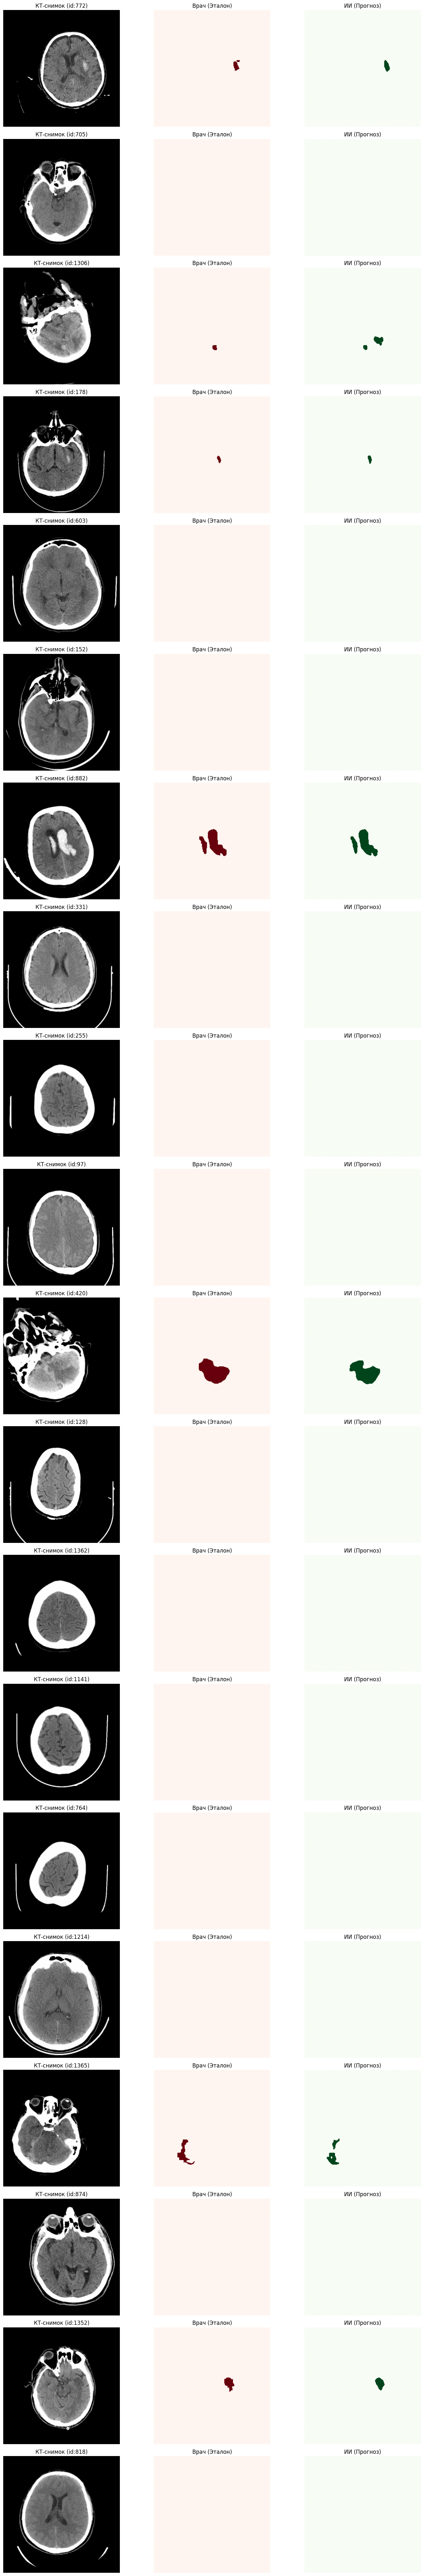

In [ ]:
val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

def plot_results(n=20):
    model.eval()

    if 'val_i' not in globals():
        print("❌ Ошибка: Список снимков 'val_i' не найден. Запусти ячейку с разделением данных!")
        return

    indices = np.random.choice(len(val_i), n)

    plt.figure(figsize=(15, 4 * n))

    for i, idx in enumerate(indices):
        ds = StrokeDataset([val_i[idx]], [val_m[idx]], val_transform)
        img, mask = ds[0]

        with torch.no_grad():
            output = model(img.unsqueeze(0).to(device))
            pred = (torch.sigmoid(output) > 0.5).cpu().numpy()[0,0]

        orig = np.clip(img.permute(1,2,0).numpy() * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406], 0, 1)

        # Столбец 1: Оригинал
        plt.subplot(n, 3, i*3 + 1)
        plt.imshow(orig)
        plt.title(f"КТ-снимок (id:{idx})")
        plt.axis('off')

        # Столбец 2: Маска врача (Красная)
        plt.subplot(n, 3, i*3 + 2)
        plt.imshow(mask[0], cmap='Reds')
        plt.title("Врач (Эталон)")
        plt.axis('off')

        # Столбец 3: Результат ИИ (Зеленый)
        plt.subplot(n, 3, i*3 + 3)
        plt.imshow(pred, cmap='Greens')
        plt.title("ИИ (Прогноз)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_results(n=20)